<a href="https://colab.research.google.com/github/satrishabh/ML-DL-GENAI/blob/main/l4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist



In [54]:
from google.colab import files
from PIL import Image

In [55]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [56]:
x_train.shape

(60000, 28, 28)

In [57]:
y_train.shape

(60000,)

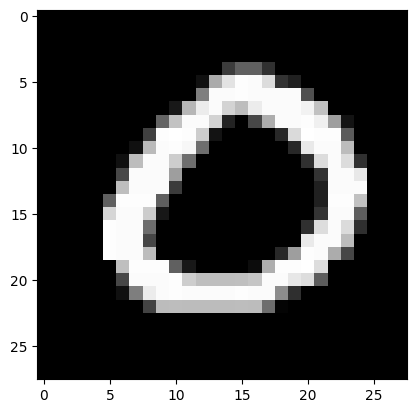

In [58]:
plt.imshow(x_train[435],cmap='gray')

In [59]:
sample_image =x_train[437]
print("top left corner of the image with dimension 15*15", sample_image[:15,:15])

top left corner of the image with dimension 15*15 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  30]
 [  0   0   0   0   0   0   0   0   0   0   0   0   8 120 215]
 [  0   0   0   0   0   0   0   0   0   0   0  17 155 254 254]
 [  0   0   0   0   0   0   0   0   0   4  88 191 254 199  82]
 [  0   0   0   0   0   0   0   0   0   6 207 254 254 218  40]
 [  0   0   0   0   0   0   0   0   0   0 125 242 208 254 254]
 [  0   0   0   0   0   0   0   0   0   0   0  42   8  54 139]]


In [60]:
print("top left corner of the image with dimension 15*15", sample_image[:,:])

top left corner of the image with dimension 15*15 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   3   6   6   1   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  11  44
  148 152 194 241 146  59   0   0   0   0]
 [  0   0   0 

In [61]:
x_train_norm=x_train.astype('float32')/255.0
x_test_norm=x_test.astype('float32')/255.0

In [62]:
x_test_norm.min()

np.float32(0.0)

In [63]:
x_train_norm.max()

np.float32(1.0)

In [64]:
sample_pixel=x_train_norm[1125]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

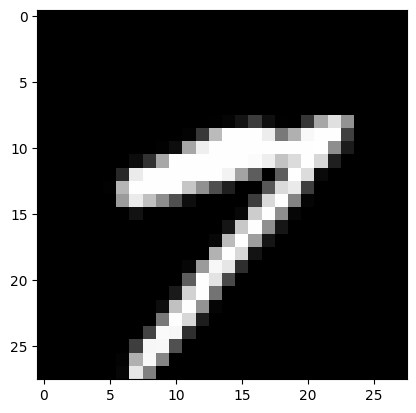

In [65]:
plt.imshow(sample_pixel,cmap='gray')
sample_pixel[:,:]

In [66]:
one_image=x_train_norm[0:1]

In [67]:
print(one_image)

[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  

In [68]:
demo_conv=layers.Conv2D(filters=4,kernel_size=(3,3),activation='relu')

since image is very large , supplying only with 1 filte it becomes time consuming in nature

In [69]:
demo_pool=layers.MaxPooling2D(pool_size=(2,2))

In [70]:
one_image=np.expand_dims(one_image,axis=-1)
conv_output=demo_conv(one_image)

In [71]:
pool_output=demo_pool(conv_output)

In [ ]:
print(f"Shape of pool_output: {pool_output.shape}")

### Formulas for Output Dimensions in Convolutional Neural Networks

**1. Convolutional Layer (Conv2D):**

Given an input image of dimensions `(Height_in, Width_in)` and a convolutional layer with:
- `Kernel_size = (K_h, K_w)`
- `Strides = (S_h, S_w)`
- `Padding = 'valid'` (no padding)
- `Filters = F` (number of output channels)

The output dimensions `(Height_out, Width_out, F)` are calculated as:

`Height_out = (Height_in - K_h) / S_h + 1`
`Width_out = (Width_in - K_w) / S_w + 1`

In our case, for `conv_output`:
- `Input_height = 28`, `Input_width = 28` (from `one_image` after `np.expand_dims` it's `(1, 28, 28, 1)`)
- `Kernel_size = (3, 3)`
- `Strides = (1, 1)` (default)
- `Padding = 'valid'` (default)
- `Filters = 4`

`Height_out = (28 - 3) / 1 + 1 = 25 + 1 = 26`
`Width_out = (28 - 3) / 1 + 1 = 25 + 1 = 26`

So, the `conv_output` has a shape of `(batch_size, 26, 26, 4)`.

**2. Pooling Layer (MaxPooling2D):**

Given an input from the previous layer with dimensions `(Height_in, Width_in)` and a pooling layer with:
- `Pool_size = (P_h, P_w)`
- `Strides = (S_h, S_w)`
- `Padding = 'valid'` (no padding)

The output dimensions `(Height_out, Width_out)` are calculated as:

`Height_out = (Height_in - P_h) / S_h + 1`
`Width_out = (Width_in - P_w) / S_w + 1`

*Note: If `strides` is not explicitly set, it defaults to `pool_size`.*

In our case, for `pool_output`:
- `Input_height = 26`, `Input_width = 26` (from `conv_output`)
- `Pool_size = (2, 2)`
- `Strides = (2, 2)` (default, as `pool_size` is `(2,2)`)
- `Padding = 'valid'` (default)

`Height_out = (26 - 2) / 2 + 1 = 24 / 2 + 1 = 12 + 1 = 13`
`Width_out = (26 - 2) / 2 + 1 = 24 / 2 + 1 = 12 + 1 = 13`

The number of filters (channels) remains the same after pooling. So, the `pool_output` has a shape of `(batch_size, 13, 13, 4)`.

In [72]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [73]:
pool_output.shape

TensorShape([1, 13, 13, 4])

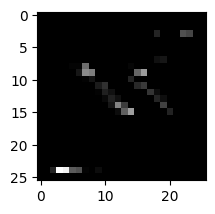

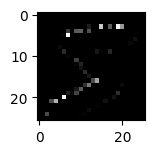

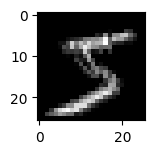

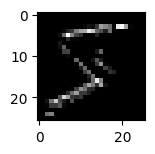

In [77]:
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(conv_output[0,:,:,i],cmap='gray')
  plt.show()

their are 4 feature map

In [79]:
demo_flatten=layers.Flatten()
flatten_output=demo_flatten(pool_output)

In [80]:
flatten_output.shape

TensorShape([1, 676])